In [1]:
from database.db import supabase
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
import datetime as dt
from predict import predict_movie, MoviePredictions, get_metrics, PredictionMetrics, default_knn_weights, KNNWeights
import time, json, random
from typing import TypedDict
import numpy as np
import os
import multiprocessing as mp

class WeightResultsForJSON(TypedDict):
    weights: KNNWeights
    k: int
    test_data_size: int
    mean_wmapd: float
    median_wmapd: float
    # predictions: list[str]
    metrics: list[str]


In [2]:
from database.types import Movie

movies_to_get = 100

movies: list[Movie] = (
    supabase.table("movie")
    .select("id, title, boxofficeday(id)")
    .lt("release_date", dt.datetime.now() - dt.timedelta(days=35))
    .gt("budget", 0)
    .order("release_date", desc=True)
    .limit(movies_to_get)
    .execute()
    .data
)

# filter out movies where the boxofficeday count is 1
movies = [movie for movie in movies if len(movie["boxofficeday"]) > 1]

print(f"Got {len(movies)} movies to predict")

Got 99 movies to predict


In [5]:
mp_chunk_size = 10
day_to_test = 1
iterations = 20
change_from_base = True
weight_change = 20
k_change = 9


starting_weights = default_knn_weights()

starting_weights = {
    "mpaa_rating": 1.2221514188873281,
    "source": 1.3162772814030204,
    "genre": 1.0857165970270608,
    "production_method": 1.6603417872596653,
    "creative_type": 0.5232242523788889,
    "budget": 0.768189489030695,
    "genres": 0.8555404847229346,
    "spoken_languages": 1.4229478228433958,
    "production_countries": 0.3095357448144358,
    "production_companies": 0.6171485343956015,
    "release_dates": 3.1793689929674476,
    "release_dates_count": 2.0804167610825504
}

starting_k = 10
starting_k = 8
weights = starting_weights.copy()
k = starting_k

manager = mp.Manager()

previous_time = time.time()
for iter in range(iterations):
    # update the weights
    for key, value in weights.items():
        if change_from_base:
            # update the weight by a random amount between -0.1 and 0.1
            weights[key] = starting_weights[key] + random.uniform(-1 * weight_change, weight_change)
        else:
            # update the weight by a random amount between -0.1 and 0.1
            weights[key] = value + random.uniform(-1 * weight_change, weight_change)

    # change k up or down 1
    k = k + random.randint(-k_change, k_change)
    k = max(1, k)

    # first do predictions in parallel

    # create a pool of workers

    with mp.Pool(processes=mp.cpu_count()) as pool:
        # create a list of arguments for each movie
        args = [
            (movie["id"], day_to_test, False, k, weights)
            for movie in movies
        ]
        # use the pool to map the function to the arguments
        predictions: list[MoviePredictions] = pool.starmap(predict_movie, args, chunksize=mp_chunk_size)

        # calculate metrics in parallel
        metrics_args = [
            (pred.actual, pred.predicted)
            for pred in predictions
        ]
        metrics: list[PredictionMetrics] = pool.starmap(
            get_metrics, metrics_args, chunksize=mp_chunk_size
        )

    print(f"Prediction and metrics took {time.time() - previous_time:.2f} seconds for {len(predictions)} movies")
    previous_time = time.time()

    # calculate mean and median wmapd
    mean_wmapd = np.mean([metric.wmapd for metric in metrics]).astype(float)
    median_wmapd = np.median([metric.wmapd for metric in metrics]).astype(float)
    print(f"Mean wmapd: {mean_wmapd}, Median wmapd: {median_wmapd}")

    # write the weights results to a file
    with open(f"weights_train/weights_{iter}_{time.time()}.json", "w") as f:
        weight_results: WeightResultsForJSON = {
            "weights": weights,
            "k": k,
            "test_data_size": len(predictions),
            "mean_wmapd": mean_wmapd,
            "median_wmapd": median_wmapd,
            # "predictions": [prediction.model_dump_json() for prediction in predictions],
            "metrics": [metric.model_dump_json() for metric in metrics],
        }
        json.dump(weight_results, f, indent=4)


    print(f"Updated weights: {weights}")

Most recent date: 2025-02-09
Skipping 3e7a7f15-2b38-4468-beee-3eb33eb378ca since it doesn't have release dates len(movie_release_dates)=0
Most recent date: 2025-01-25
Most recent date: 2024-12-21
Most recent date: 2024-09-28
Most recent date: 2025-02-09
Most recent date: 2024-11-23
Skipping 3e7a7f15-2b38-4468-beee-3eb33eb378ca since it doesn't have release dates len(movie_release_dates)=0
Most recent date: 2025-02-08
Most recent date: 2025-03-23
Most recent date: 2024-12-14
Skipping 3e7a7f15-2b38-4468-beee-3eb33eb378ca since it doesn't have release dates len(movie_release_dates)=0
Most recent date: 2024-08-25
Skipping 3e7a7f15-2b38-4468-beee-3eb33eb378ca since it doesn't have release dates len(movie_release_dates)=0
Most recent date: 2024-09-29
Most recent date: 2025-01-18
Skipping 3e7a7f15-2b38-4468-beee-3eb33eb378ca since it doesn't have release dates len(movie_release_dates)=0
Most recent date: 2024-12-22
Most recent date: 2025-02-08
Skipping 3e7a7f15-2b38-4468-beee-3eb33eb378ca sin

ValidationError: 1 validation error for MoviePredictions
movie.wikipedia_key
  Input should be a valid string [type=string_type, input_value=None, input_type=NoneType]
    For further information visit https://errors.pydantic.dev/2.10/v/string_type

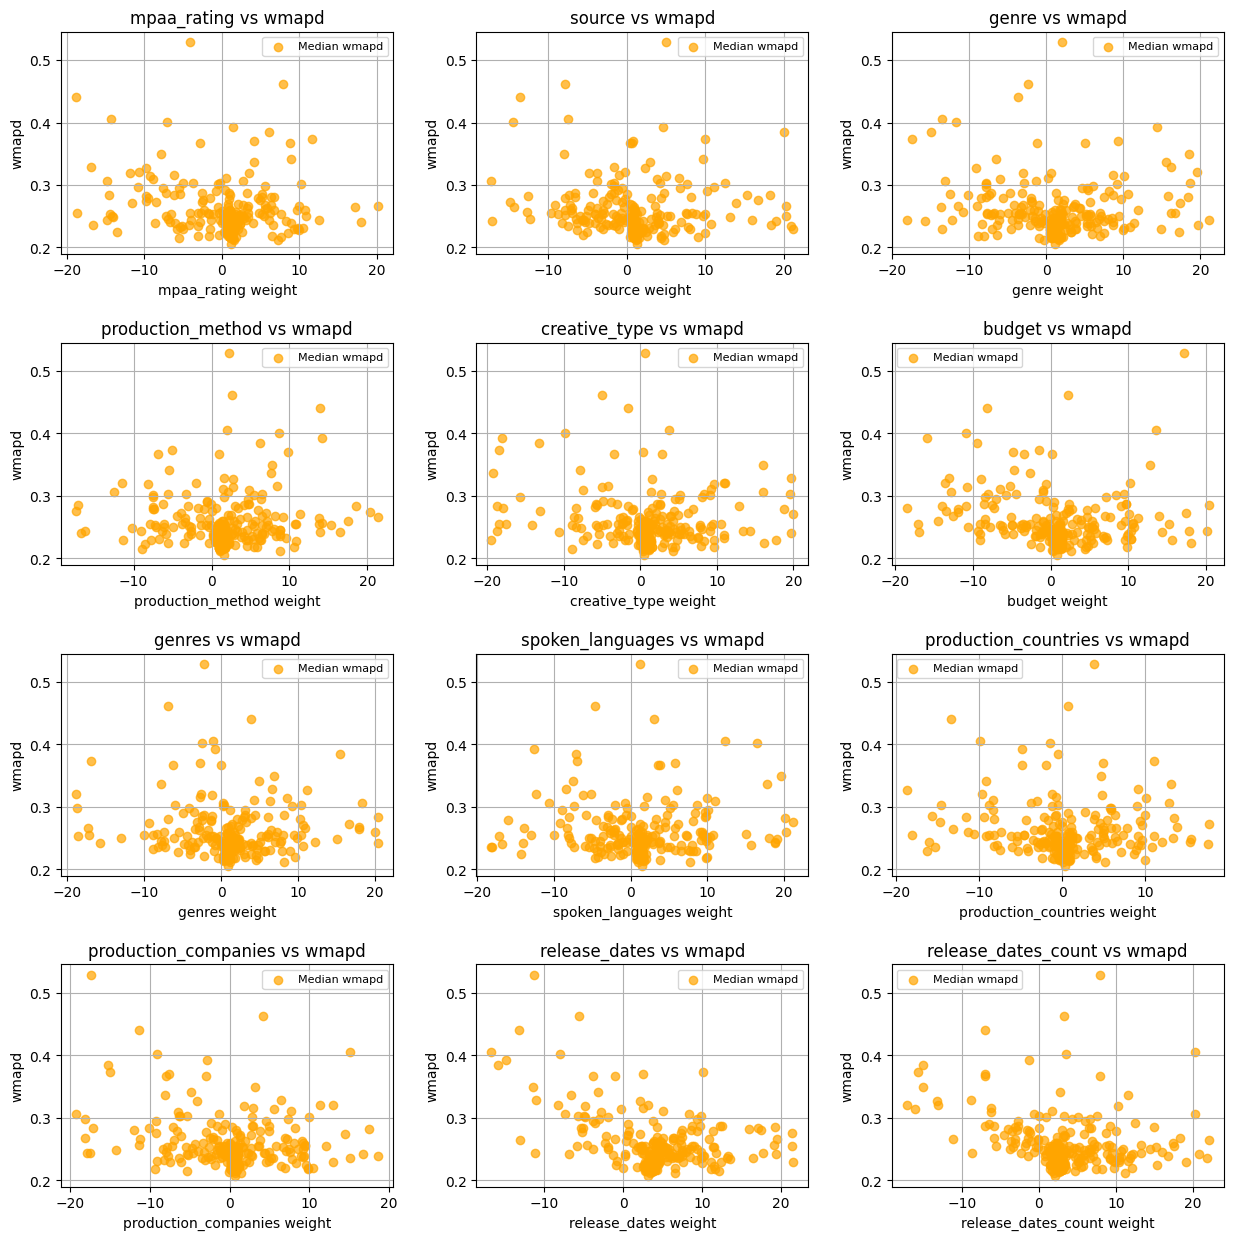

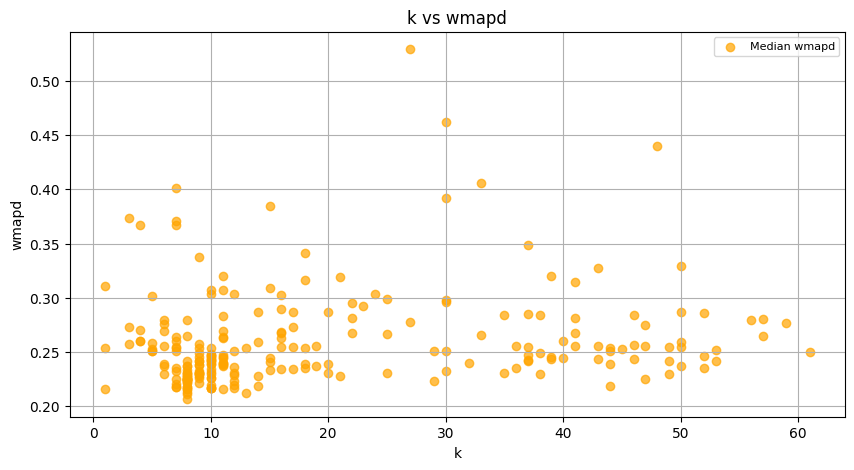

In [4]:
# plot weights vs metrics
weights: list[WeightResultsForJSON] = []

files = os.listdir("weights_train")
files = [file for file in files if file.endswith(".json")]

# open each file and load the json
for file in files:
    with open(f"weights_train/{file}", "r") as f:
        weight_results: WeightResultsForJSON = json.load(f)
        weights.append(weight_results)
""" For each of these, plot the value again the mean wmapd and median wmapd
"weights": {
    "mpaa_rating": 0.7845565864204541,
    "source": 1.2795897689061217,
    "genre": 1.9166262752450418,
    "production_method": 0.8554753326275034,
    "creative_type": -0.33720316223435887,
    "budget": 0.9850147964925106,
    "genres": 1.3945102037502222,
    "spoken_languages": 1.4047544530148013,
    "production_countries": -0.7404661884130712,
    "production_companies": 1.0187338823014689,
    "release_dates": 5.373114760398118,
    "release_dates_count": 2.1262103073855076
},
"k": 7,
"""

plot_mean = False
plot_median = True

weight_keys = [
    "mpaa_rating",
    "source",
    "genre",
    "production_method",
    "creative_type",
    "budget",
    "genres",
    "spoken_languages",
    "production_countries",
    "production_companies",
    "release_dates",
    "release_dates_count"
]

# create subplots
fig, axs = plt.subplots(4, 3, figsize=(15, 15))
fig.subplots_adjust(hspace=0.4, wspace=0.25)
axs = axs.flatten()
for key in weight_keys:
    # get the weights for this key
    weight_values = [weight["weights"][key] for weight in weights]
    ax = axs[weight_keys.index(key)]

    if plot_mean:
        mean_wmapd = [weight["mean_wmapd"] for weight in weights]
        ax.scatter(weight_values, mean_wmapd, label="Mean wmapd", color="blue", alpha=0.7)
    if plot_median:
        median_wmapd = [weight["median_wmapd"] for weight in weights]
        ax.scatter(weight_values, median_wmapd, label="Median wmapd", color="orange", alpha=0.7)

    # plot the values
    ax.set_xlabel(f"{key} weight", fontsize=10)
    ax.set_ylabel("wmapd", fontsize=10)
    ax.set_title(f"{key} vs wmapd", fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True)

# also plot the k vs mean and median wmapd
k_values = [weight["k"] for weight in weights]
plt.figure(figsize=(10, 5))
if plot_mean:
    mean_wmapd = [weight["mean_wmapd"] for weight in weights]
    plt.scatter(k_values, mean_wmapd, label="Mean wmapd", color="blue", alpha=0.7)
if plot_median:
    median_wmapd = [weight["median_wmapd"] for weight in weights]
    plt.scatter(k_values, median_wmapd, label="Median wmapd", color="orange", alpha=0.7)
plt.xlabel("k", fontsize=10)
plt.ylabel("wmapd", fontsize=10)
plt.title("k vs wmapd", fontsize=12)
plt.legend(fontsize=8)
plt.grid(True)